In [1]:
import os
import scanpy as sc
import numpy as np
import pandas as pd
import giniclust3 as gc
import anndata as ad

/home/jsl/anaconda3/envs/GiniClust3/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Gene number is 12152
Cell number is 37450


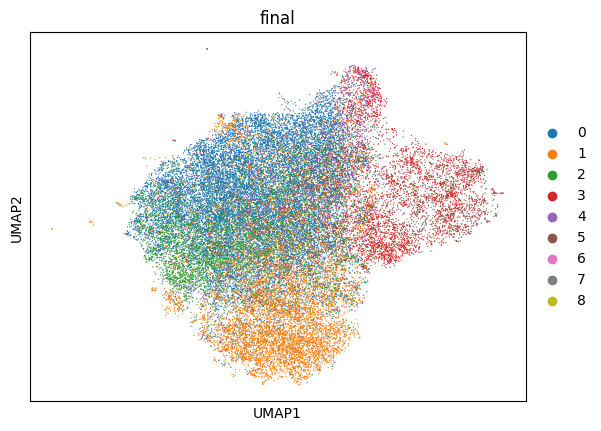

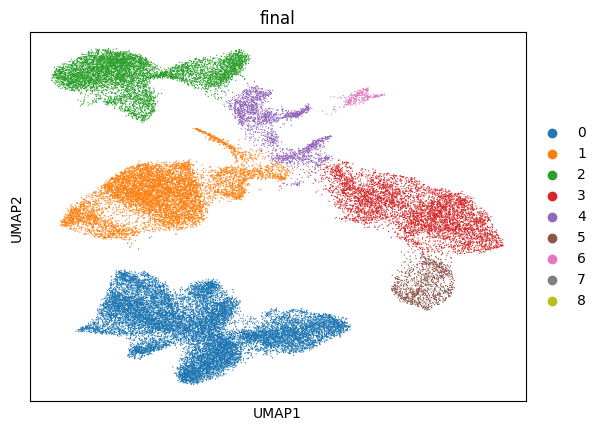

In [2]:
os.chdir('./ComicGTN/data/BMMC-bench-1')

data_mat  = sc.read('Gene_Cell.mtx')
geneNames  = pd.read_csv('Gene_names.tsv', sep='\t', header=None)
cellNames  = pd.read_csv('Cell_names.tsv', sep='\t', header=None)
labels = pd.read_csv('Cell_types.tsv', sep='\t', header=None)

adataSC=ad.AnnData(X=data_mat.X.toarray().T,obs=pd.DataFrame(index=cellNames[0]),var=pd.DataFrame(index=geneNames[0]))
sc.pp.normalize_per_cell(adataSC, counts_per_cell_after=1e4)
gc.gini.calGini(adataSC) ###Calculate Gini Index
adataGini=gc.gini.clusterGini(adataSC,neighbors=3) ###Cluster based on Gini Index

gc.fano.calFano(adataSC) ###Calculate Fano factor
adataFano=gc.fano.clusterFano(adataSC) ###Cluster based on Fano factor
consensusCluster={}
consensusCluster['giniCluster']=np.array(adataSC.obs['rare'].values.tolist())
consensusCluster['fanoCluster']=np.array(adataSC.obs['fano'].values.tolist())
gc.consensus.generateMtilde(consensusCluster) ###Generate consensus matrix
gc.consensus.clusterMtilde(consensusCluster) ###Cluster consensus matrix
adataGini.obs['final']=consensusCluster['finalCluster']
adataFano.obs['final']=consensusCluster['finalCluster']
gc.plot.plotGini(adataGini)
gc.plot.plotFano(adataFano)

rare_label_pred = consensusCluster['finalCluster']
pd.DataFrame(rare_label_pred).to_csv("./ComicGTN/data/BMMC-bench-1/GiniClust3_pred.tsv", sep="\t", header=False, index=False)